# Customer Segmentation and Churn Prediction Using Machine Learning

## 1. Introduction and Problem Formulation

In the telecommunications sector, acquiring a new customer is significantly more expensive than retaining an existing one. Therefore, the metric of identifying customers who are likely to cancel their service, known as **Customer Churn**, is a critical, high-value business problem.

While traditional analytics can show *how many* people left, Machine Learning allows us to predict *who* will leave and *why*. 

### Project Objectives and Scope
This technical report explores customer retention through a two-step machine learning pipeline:
1. **Unsupervised Learning (Clustering):** Before predicting churn, we will use K-Means clustering to discover hidden segments within the customer base based on their usage patterns and demographics.
2. **Supervised Learning (Classification):** We will engineer features and train classification models (Logistic Regression and Random Forest) to predict the binary target variable (`Churn`). 

By combining these methods, we can flag high-risk customers and also understand which specific customer segment they belong to, allowing the business to tailor its retention strategies effectively.

## 2. Data Ingestion and Initial Inspection

The foundation of any robust machine learning pipeline is a thorough understanding of the raw data. We are utilizing the **Telco Customer Churn** dataset, which includes customer demographics (e.g., gender, senior citizen status), account information (e.g., tenure, contract type, payment method), and our target variable (`Churn`).

First, we will load the dataset and inspect its structure, data types, and check for any immediate data quality issues such as missing values.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the entire notebook
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('../data/telco_churn.csv')

print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

print("--- Data Types and Missing Values ---")
df.info()

print("\n--- First 3 Rows ---")
display(df.head(3))

Dataset Shape: 7043 rows and 21 columns.

--- Data Types and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 3. Exploratory Data Analysis (EDA)

Before engineering features for our models, we must understand the underlying distributions and relationships within our data. We will focus on three key areas:
1. **Target Variable Distribution:** Understanding the class balance of our `Churn` column.
2. **Numeric Feature Analysis:** How does customer `tenure` (months with the company) and `MonthlyCharges` affect churn?
3. **Categorical Feature Analysis:** Does the type of `Contract` (Month-to-month vs. Two year) influence retention?

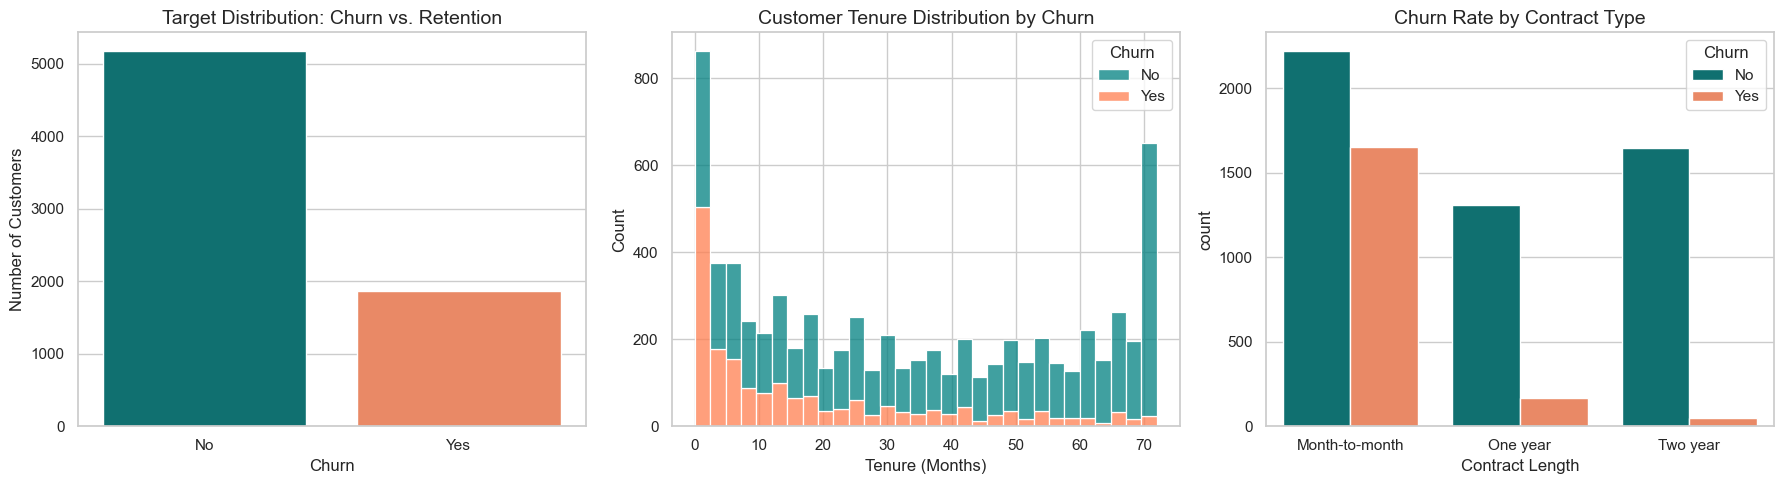

In [6]:
# Create a figure with 3 subplots for a professional layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target Variable Distribution (Class Imbalance)
sns.countplot(data=df, x='Churn', hue='Churn', ax=axes[0], palette=['teal', 'coral'])
axes[0].set_title('Target Distribution: Churn vs. Retention', fontsize=14)
axes[0].set_ylabel('Number of Customers')

# Plot 2: Numeric Feature - Tenure vs. Churn
sns.histplot(data=df, x='tenure', hue='Churn', multiple="stack", bins=30, ax=axes[1], palette=['teal', 'coral'])
axes[1].set_title('Customer Tenure Distribution by Churn', fontsize=14)
axes[1].set_xlabel('Tenure (Months)')

# Plot 3: Categorical Feature - Contract Type vs. Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[2], palette=['teal', 'coral'])
axes[2].set_title('Churn Rate by Contract Type', fontsize=14)
axes[2].set_xlabel('Contract Length')

plt.tight_layout()
plt.show()